## Interpolation theorem in Signal processing

A classic result in signal processing is the **interpolation theorem**, stating that it is possible to exactly recover a whole signal $(x(t))_{t \in \mathbb{R}}$ over all $\mathbb{R}$ by only knowing its value on the discrete grid $(nT_e)_{n \in \mathbb{Z}}$, at the sole condition that $T_e$, the sampling period, verifyies the condition $F_e=\frac1{T_e} \geq 2B$, where $B=f_{\text{max}}-f_{\text{min}}$. $f_{\text{max}}$ and $f_{\text{min}} \geq 0$ are respectively the largest and smallest frequencies in the spectre of $x$. Of course, if $f_{\text{max}} = +\infty$, then this theorem does not provide an answer, but it might be impossible. Also, notice that if $f_{\text{min}}=0$, then one recovers the well-known Shannon's theorem, stating that the condition to prevent anti-aliasing is $F_e \geq 2f_{\text{max}}$.

Moreover, the theorem also provides an explicit formula:

$\forall t \in \mathbb{R}$:
$$
x(t) = \sum_{n=-\infty}^{+\infty} x(nT_e)\frac{\sin(\pi F_e(t-nT_e))}{\pi F_e(t-nT_e)} = \sum_{n=-\infty}^{+\infty} x(nT_e)\text{sinc}(\pi F_e(t-nT_e)).
$$

I am going to check this formula by implementing Python code and try to gain an intuition on its speed of convergence. The computer can not store an infinite sequence, or compute an infinite serie, so we are going to truncate it via an integer $N$, that is:
$$
\tilde x(t)= \sum_{n=-N}^{N} x(nT_e)\frac{\sin(\pi F_e(t-nT_e))}{\pi F_e(t-nT_e)}
$$
and observe how well $\tilde x(t)$ approximates $x(t)$ by comparing graphs.

Assume that one wants to plot $\hat x$ over an interval $[T_a, T_b]$. To use $x$ over this whole interval, one must choose $N \geq \displaystyle\lceil \frac{T_b-T_a}{2T_e} \rceil$.

**In practice however, this method is not popular for signal reconstruction.**

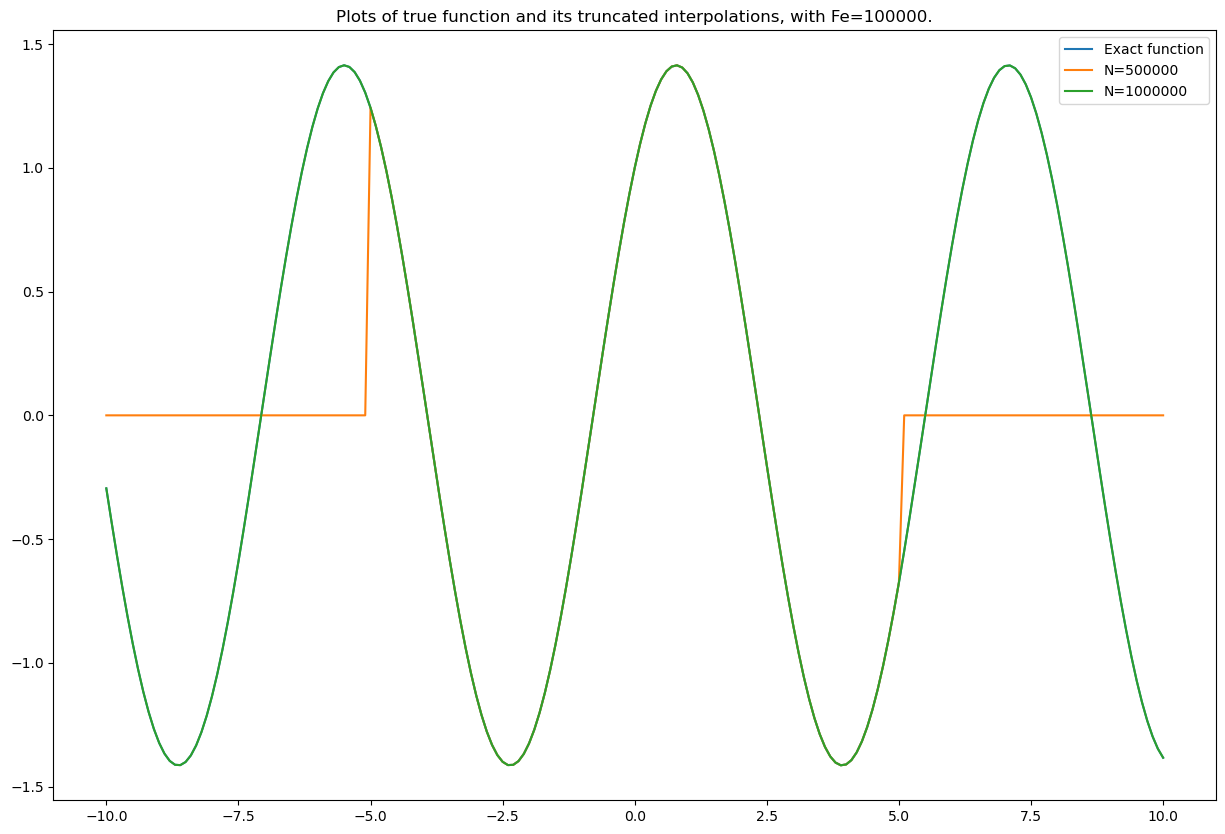

[array([-1.79425207e-15,  3.85298021e-15, -3.79047495e-15, -2.94955354e-15,
       -1.46973784e-15, -1.91197391e-15, -1.48380361e-15, -3.55584288e-15,
       -6.55001973e-15,  1.50816531e-16, -2.88875293e-15, -3.06166640e-15,
       -7.43609129e-17, -1.55110751e-15, -1.36405932e-15, -1.32406166e-15,
       -4.20019260e-16, -2.60891446e-15, -2.86434535e-15, -4.12831769e-15,
       -4.09063267e-15,  1.95941121e-15,  3.91950090e-15, -5.74440311e-15,
       -4.49074378e-15, -1.65705469e-15, -1.70675589e-15,  5.40049885e-15,
       -5.13870926e-15, -2.66992488e-15, -1.86222446e-15, -5.41819651e-15,
        1.61578514e-15, -5.20975618e-15, -3.87818220e-15, -1.13185589e-15,
       -5.56275317e-15, -1.50804608e-17, -7.70626099e-15, -1.04760117e-14,
       -4.91424329e-15, -6.05701165e-15,  4.86571485e-15,  1.39364989e-15,
       -2.55591818e-16,  6.66382756e-16, -1.90143184e-15,  2.49472132e-15,
       -9.67506938e-15, -7.06103124e-15,  1.24258646e+00,  1.16896498e+00,
        1.08366359e+00, 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def exact_interpolation(f: callable, T: np.ndarray, N: int, Fe: float, X: np.ndarray=None):
    """Compute an approximation of the exact interpolation formula, see above.
    The total number of element in the sum is 2N+1.

    Args:
        f (callable): signal to approximate.
        T (np.ndarray): Time points where to evalute interpolation.
        N (int): Number of signal element on time positive axis.
        Fe (float): sampling frequency.
        X (np.ndarray): In case f is not provided, X should be the signal recorded at sampling frequency Fe.
    """
    Te=1/Fe
    assert f is not None or X is not None, "f or X should be provided."
    if f is not None:
        Int=np.linspace(-N, N, 2*N+1)*Te
        return np.array([np.sum(f(Int)*np.sinc(Fe*(t-Int))) for t in T])
    else:
        Int=np.array(range(len(X)))*Te
        return np.array([np.sum(X[range(len(X))]*np.sinc(Fe*(t-Int))) for t in T])

def compare_with_plots(f:callable, T:np.ndarray, X:np.ndarray=None):
    Fe=1e5
    N_min=np.ceil((T[-1] - T[0])*Fe/2).astype(int)
    N=[np.floor(N_min*.5).astype(int), N_min]
    Result=[]
    F=f(T)
    for n in N:
        Result += [exact_interpolation(f=f, T=T, N=n, Fe=Fe, X=X)]
    fig=plt.figure(figsize=(15,10))
    ax=fig.add_subplot(111)
    ax.plot(T,F, label='Exact function')
    for i,n in enumerate(N):
        ax.plot(T, Result[i], label=f"N={n}")
    ax.set_title(f'Plots of true function and its truncated interpolations, with Fe={int(Fe)}.')
    plt.legend()
    plt.show()
    print(Result)

#Very regular function
sin_cos=lambda x: np.sin(x) + np.cos(x)

compare_with_plots(sin_cos, T=np.linspace(-10,10,201))